# Khisto Demo

This notebook demonstrates the main functionalities of the Khisto library for optimal histogram binning.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data
np.random.seed(42)
data = np.concatenate(
    [
        np.random.normal(-2, 0.5, 300),
        np.random.normal(1, 1.5, 700),
    ]
)
print(f"Data shape: {data.shape}")
print(f"Data range: [{data.min():.2f}, {data.max():.2f}]")

Data shape: (1000,)
Data range: [-3.62, 5.62]


## 1. NumPy-like API: `khisto.histogram`

Drop-in replacement for `numpy.histogram` with optimal binning.

In [2]:
from khisto import histogram

# Compute optimal histogram
hist, bin_edges = histogram(data)

print(f"Number of bins: {len(hist)}")
print(f"Bin edges: {bin_edges}")
print(f"Frequencies: {hist}")

Number of bins: 7
Bin edges: [-3.625 -3.    -2.625 -1.5   -0.25   2.125  3.875  5.625]
Frequencies: [  4.  28. 255. 140. 420. 136.  17.]


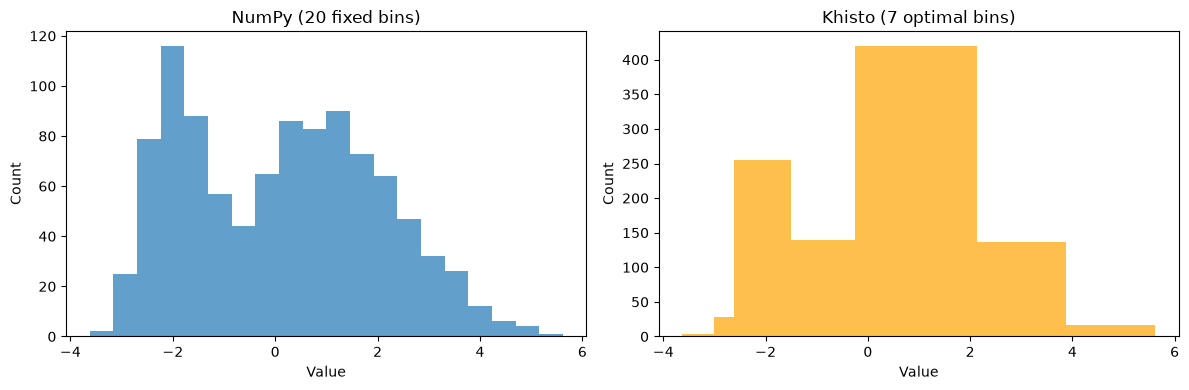

In [3]:
# Compare with numpy fixed-width bins
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# NumPy histogram (fixed bins)
np_hist, np_edges = np.histogram(data, bins=20)
axes[0].stairs(np_hist, np_edges, fill=True, alpha=0.7)
axes[0].set_title("NumPy (20 fixed bins)")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Count")

# Khisto histogram (optimal bins)
axes[1].stairs(hist, bin_edges, fill=True, alpha=0.7, color="orange")
axes[1].set_title(f"Khisto ({len(hist)} optimal bins)")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

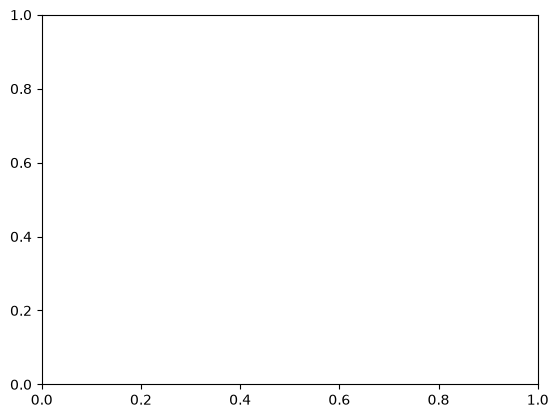

In [4]:
from khisto import matplotlib
matplotlib.hist([data, [1, 2, 3], [2,2,2,2]], max_bins=20, alpha=0.5)

(array([[  2.,  25.,  79., 116.,  88.,  57.,  44.,  65.,  86.,  83.,  90.,
          73.,  64.,  47.,  32.,  26.,  12.,   6.,   4.,   1.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,
           0.,   1.,   0.,   1.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   4.,   0.,   0.,   0.,   0.,   0.,   0.,   0.]]),
 array([-3.62063367, -3.15868593, -2.69673818, -2.23479044, -1.77284269,
        -1.31089495, -0.84894721, -0.38699946,  0.07494828,  0.53689603,
         0.99884377,  1.46079152,  1.92273926,  2.384687  ,  2.84663475,
         3.30858249,  3.77053024,  4.23247798,  4.69442572,  5.15637347,
         5.61832121]),
 <a list of 3 BarContainer objects>)

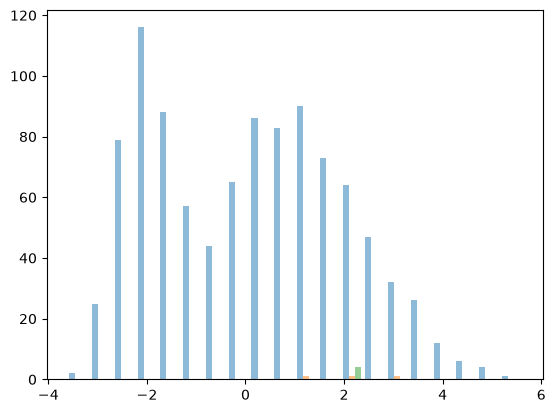

In [5]:
plt.hist([data, [1, 2, 3], [2,2,2,2]], bins=20, alpha=0.5)

In [6]:
# With density normalization
density, bin_edges = histogram(data, density=True)

# Verify normalization (integral should be ~1)
widths = np.diff(bin_edges)
integral = np.sum(density * widths)
print(f"Integral of density: {integral:.6f}")

Integral of density: 1.000000


In [7]:
# With max_bins limit
hist_limited, edges_limited = histogram(data, max_bins=5)
print(f"Limited to max 5 bins: got {len(hist_limited)} bins")
print(f"Bin edges: {edges_limited}")

Limited to max 5 bins: got 4 bins
Bin edges: [-3.625 -2.     2.     4.     5.625]


In [8]:
# With range specification
hist_range, edges_range = histogram(data, range=(-3, 3))
print(f"Range [-3, 3]: {len(hist_range)} bins")
print(f"Bin edges: {edges_range}")

Range [-3, 3]: 5 bins
Bin edges: [-3.  -2.5 -1.5  0.   2.   3. ]


## 2. Matplotlib API: `khisto.matplotlib.hist`

Plot optimal histograms with a matplotlib-like interface.

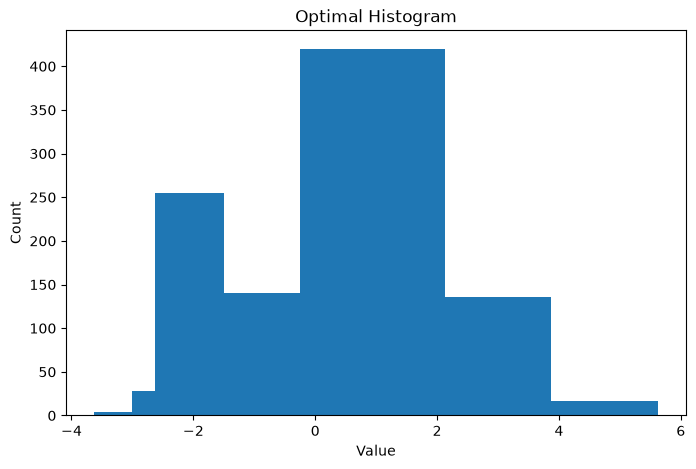

Returned 7 bin values


In [9]:
from khisto.matplotlib import hist

# Basic histogram plot
fig, ax = plt.subplots(figsize=(8, 5))
n, bins, patches = hist(data, ax=ax)
ax.set_xlabel("Value")
ax.set_ylabel("Count")
ax.set_title("Optimal Histogram")
plt.show()

print(f"Returned {len(n)} bin values")

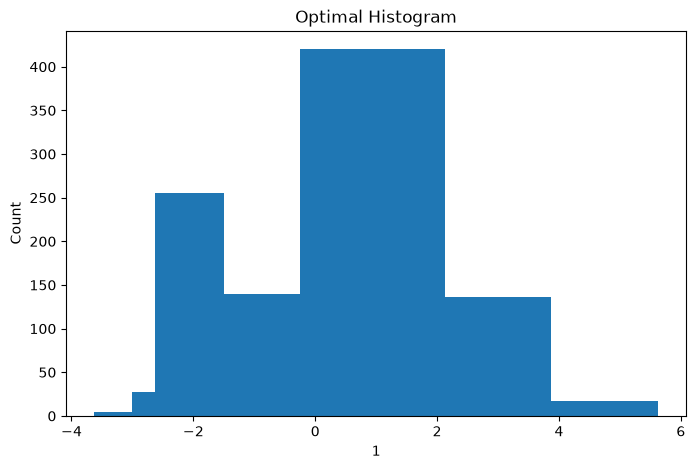

In [12]:
# Basic histogram plot
fig, ax = plt.subplots(figsize=(8, 5))
n, bins, patches = hist(data, ax=ax, label=1)
# ax.set_xlabel("Value")
ax.set_xlabel(1)
ax.set_ylabel("Count")
ax.set_title("Optimal Histogram")
plt.show()

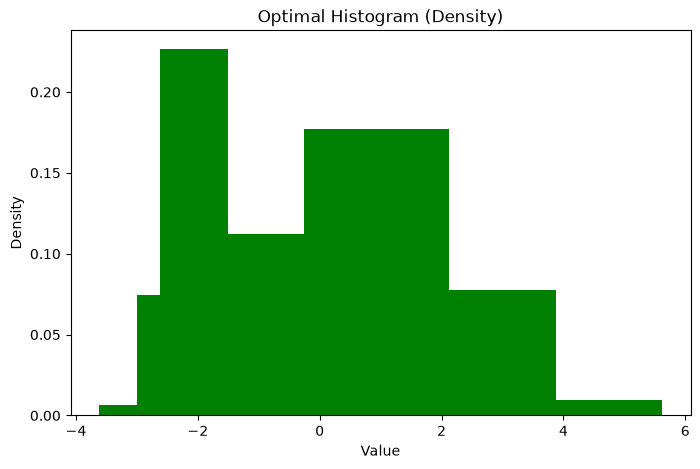

In [16]:
# Density plot
fig, ax = plt.subplots(figsize=(8, 5))
n, bins, patches = hist(data, density=True, ax=ax, color="green")
ax.set_xlabel("Value")
ax.set_ylabel("Density")
ax.set_title("Optimal Histogram (Density)")
plt.show()

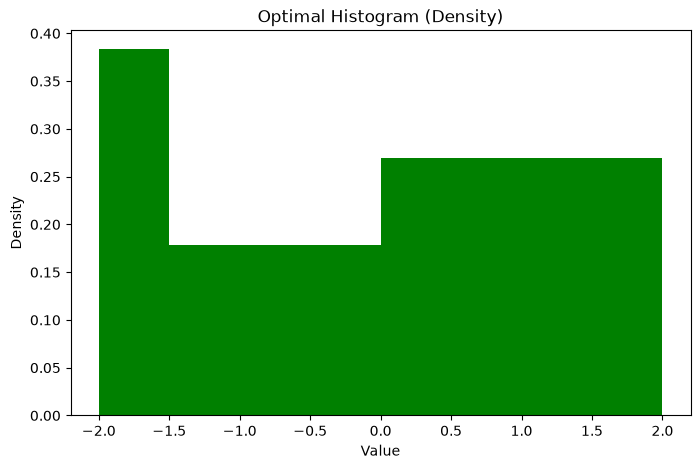

In [17]:
# Density plot
fig, ax = plt.subplots(figsize=(8, 5))
n, bins, patches = hist(data, density=True, range=(-2, 2), ax=ax, color="green")
ax.set_xlabel("Value")
ax.set_ylabel("Density")
ax.set_title("Optimal Histogram (Density)")
plt.show()

### Cumulative plots with `khisto.matplotlib.hist`

`khisto.matplotlib.hist` supports matplotlib-style cumulative plots, including reverse cumulative counts and cumulative probabilities.

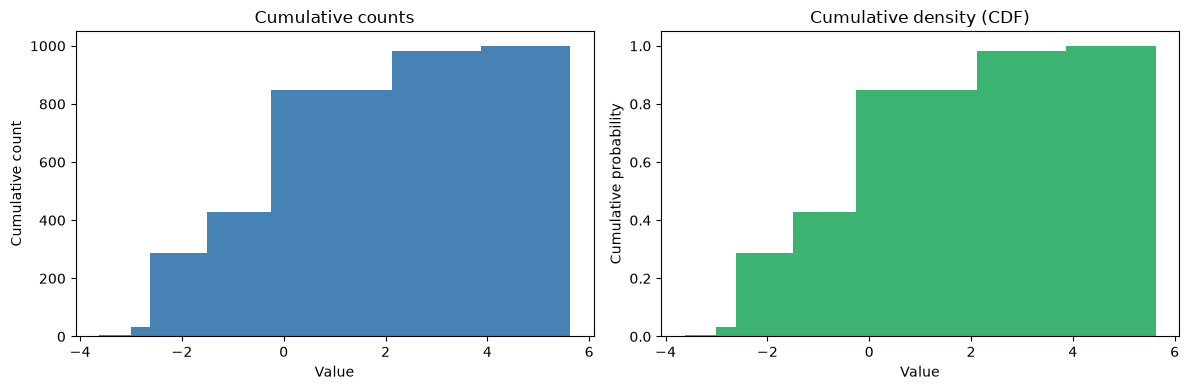

Last cumulative count: 1000
Last cumulative probability: 1.000000


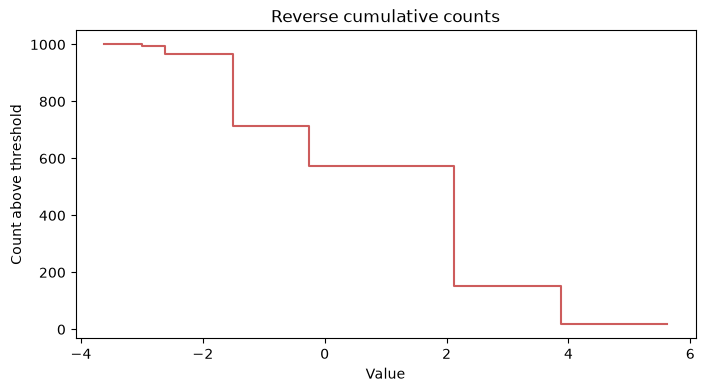

First reverse cumulative count: 1000


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cum_n, cum_bins, _ = hist(data, cumulative=True, ax=axes[0], color="steelblue")
axes[0].set_title("Cumulative counts")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Cumulative count")

cdf_n, cdf_bins, _ = hist(
    data,
    density=True,
    cumulative=True,
    ax=axes[1],
    color="mediumseagreen",
)
axes[1].set_title("Cumulative density (CDF)")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Cumulative probability")
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print(f"Last cumulative count: {cum_n[-1]:.0f}")
print(f"Last cumulative probability: {cdf_n[-1]:.6f}")

fig, ax = plt.subplots(figsize=(8, 4))
reverse_n, reverse_bins, _ = hist(
    data,
    cumulative=-1,
    ax=ax,
    color="indianred",
    histtype="step",
)
ax.set_title("Reverse cumulative counts")
ax.set_xlabel("Value")
ax.set_ylabel("Count above threshold")
plt.show()

print(f"First reverse cumulative count: {reverse_n[0]:.0f}")

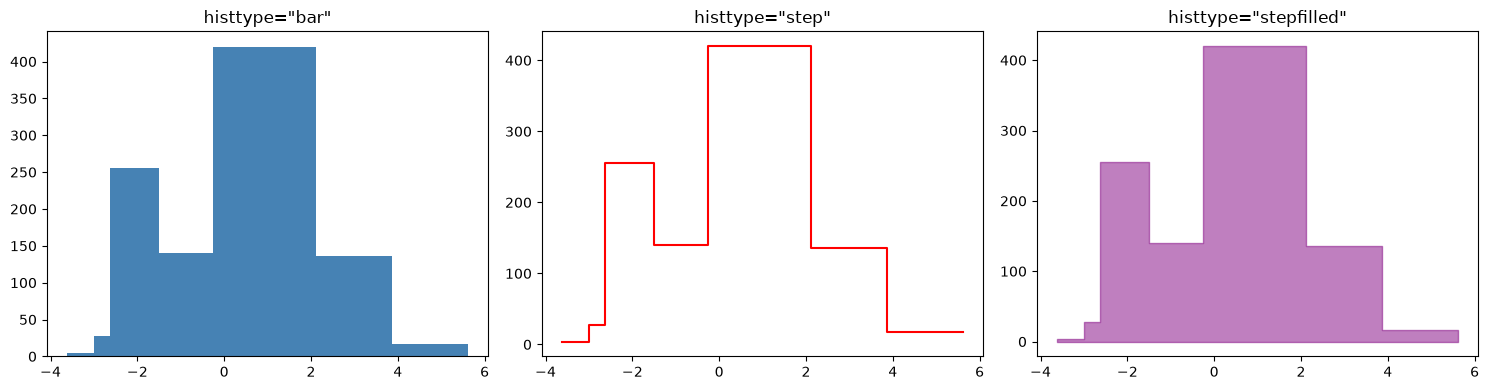

In [19]:
# Different histogram types
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

hist(data, histtype="bar", ax=axes[0], color="steelblue")
axes[0].set_title('histtype="bar"')

hist(data, histtype="step", ax=axes[1], color="red")
axes[1].set_title('histtype="step"')

hist(data, histtype="stepfilled", ax=axes[2], color="purple", alpha=0.5)
axes[2].set_title('histtype="stepfilled"')

plt.tight_layout()
plt.show()

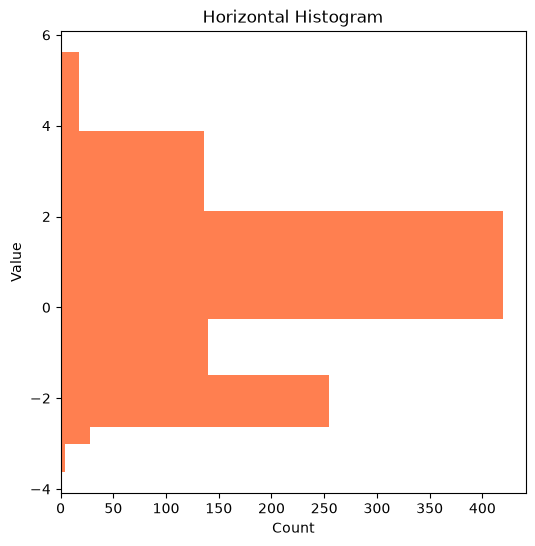

In [20]:
# Horizontal orientation
fig, ax = plt.subplots(figsize=(6, 6))
hist(data, orientation="horizontal", ax=ax, color="coral")
ax.set_xlabel("Count")
ax.set_ylabel("Value")
ax.set_title("Horizontal Histogram")
plt.show()

## 3. Core API: `compute_histogram` and `HistogramResult`

Direct access to detailed histogram information.

In [21]:
from khisto.core import compute_histograms

# Get all granularity levels
results = compute_histograms(data)

print(f"Number of granularity levels: {len(results)}")
print("\nGranularity levels:")
for r in results:
    marker = " ← BEST" if r.is_best else ""
    print(f"  Granularity {r.granularity}: {len(r.frequencies)} bins{marker}")

Number of granularity levels: 7

Granularity levels:
  Granularity 0: 1 bins
  Granularity 1: 2 bins
  Granularity 2: 2 bins
  Granularity 3: 4 bins
  Granularity 4: 7 bins
  Granularity 5: 8 bins
  Granularity 7: 7 bins ← BEST


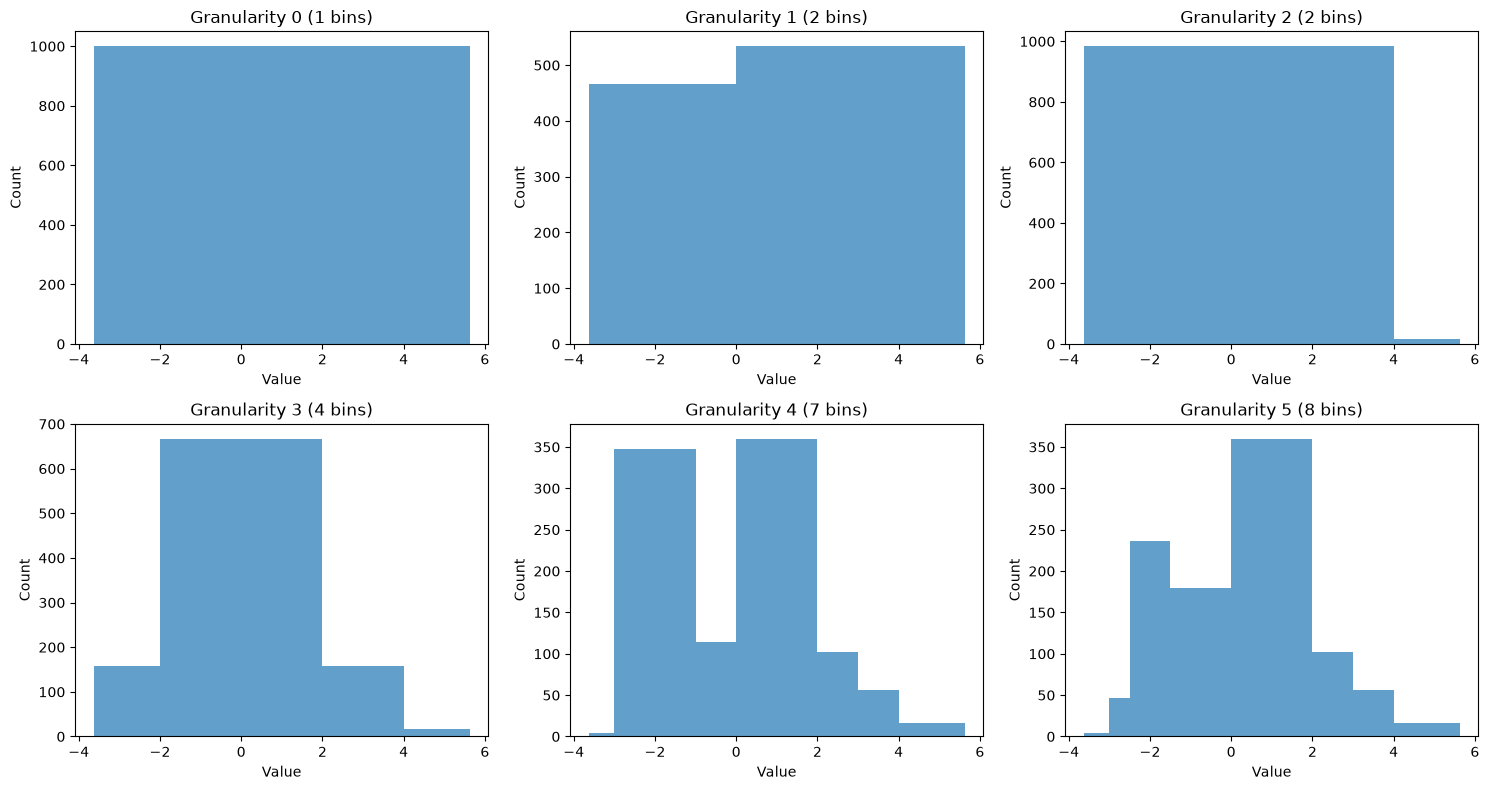

In [22]:
# Visualize different granularities
n_levels = min(6, len(results))
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, r in enumerate(results[:n_levels]):
    ax = axes[i]
    ax.stairs(r.frequencies, r.bin_edges, fill=True, alpha=0.7)
    title = f"Granularity {r.granularity} ({len(r.frequencies)} bins)"
    if r.is_best:
        title += " ★ BEST"
        ax.set_facecolor("#ffffee")
    ax.set_title(title)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## Summary

Khisto provides four complementary API levels:

1. **`khisto.histogram`** - NumPy-compatible, returns `(hist, bin_edges)`
2. **`khisto.cumfreq`** - SciPy-like cumulative histogram with adaptive bins
3. **`khisto.matplotlib.hist`** - Matplotlib-compatible, plots directly
4. **`khisto.core.compute_histogram`** - Full access to `HistogramResult` with all details